![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab: Text-to-Speech (TTS)

This notebook guides you through **text-to-speech synthesis** — from mel-spectrogram front-ends and duration modeling to Hugging Face neural TTS inference.

You will connect lecture concepts (autoregressive vs parallel acoustic models, evaluation metrics) to hands-on PyTorch and `transformers` code.

> 💡 TTS is a full pipeline: text normalization → linguistic features → acoustic model → vocoder. Keep that stack in mind as you implement each block.

__Let's begin with environment setup.__ First, we install the required dependencies.




## 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch (`torch`, `torchaudio`)** — Tensor operations and audio I/O for mel features.
- **Transformers** — Pretrained TTS models on the Hugging Face Hub.
- **Librosa / SoundFile** — Audio loading and spectral analysis.
- **Matplotlib / NumPy** — Visualization and numerical utilities.


In [ ]:
!pip install -q torch torchaudio transformers datasets accelerate diffusers librosa soundfile matplotlib numpy scipy


## 📥 Importing Essential Python Libraries

In this cell we import core libraries and verify GPU availability for optional neural TTS inference in Part B.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


## 🛠️ Hugging Face TTS inference

Use a pretrained model from the Hugging Face Hub to synthesize speech and reflect on the pipeline.

**Tasks:**
1. Load `facebook/mms-tts-eng` (or `suno/bark-small` if MMS fails).
2. Synthesize the sentence: *"Welcome to KAUST Academy."*
3. Play audio in Colab with `IPython.display.Audio`.
4. In a markdown cell, note whether the model is **two-stage** (text→mel→wave) or **single-stage**.


In [ ]:
SENTENCE = "Welcome to KAUST Academy."

try:
    from IPython.display import Audio, display
    from transformers import VitsModel, AutoTokenizer
    import torch
    import soundfile as sf # Import soundfile for saving audio

    tts_model = VitsModel.from_pretrained("facebook/mms-tts-eng")
    tts_tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-eng")
    inputs = tts_tokenizer(SENTENCE, return_tensors="pt")
    with torch.no_grad():
        waveform_out = tts_model(**inputs).waveform
    sample_rate = tts_model.config.sampling_rate

    # Save the audio to a WAV file
    output_filename = "output_mms_tts.wav"
    sf.write(output_filename, waveform_out.squeeze().numpy(), sample_rate)
    print(f"Audio saved to {output_filename}")

    display(Audio(waveform_out.squeeze().numpy(), rate=sample_rate))
    print("Model: MMS-TTS (VITS) — single-stage text-to-waveform.")
except Exception as exc:
    print(f"TTS demo skipped ({exc}).")
    sr = 22050
    import numpy as np # Import numpy for fallback
    t = torch.linspace(0, 2.0, 2 * sr)
    fallback = 0.2 * torch.sin(2 * np.pi * 440 * t)
    print(f"Generated fallback waveform with {fallback.numel()} samples at {sr} Hz.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/413 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

Audio saved to output_mms_tts.wav


Model: MMS-TTS (VITS) — single-stage text-to-waveform.


#### 👀 Reflection

**MMS-TTS (VITS)** is a **single-stage end-to-end** model: a text encoder, duration predictor, flow-based decoder, and HiFi-GAN-style vocoder are trained jointly. Text embeddings are upsampled by predicted durations, passed through normalizing flows, and decoded directly to waveform — no separate two-stage mel→vocoder pipeline at inference.

## 🛠️ Generating Synthetic Voices

### Helper Functions

Feel free to use and change them as needed.

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

def generate_mel_spectrogram(audio, sr=16000, n_fft=1024, hop_length=512, n_mels=128,
                             fmin=20, fmax=8000, plot=True, ax=None):
    # calculate mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax
    )

    # convert to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 4))

        img = librosa.display.specshow(
            mel_spec_db,
            x_axis='time',
            y_axis='mel',
            sr=sr,
            fmax=fmax,
            ax=ax
        )
        ax.set_title('Mel Spectrogram')
        plt.colorbar(img, ax=ax, format='%+2.0f dB')

    return mel_spec, mel_spec_db

def visualize_waveform(audio, sr=16000, plot=True, ax=None):
    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 3))

        librosa.display.waveshow(audio, sr=sr, ax=ax)
        ax.set_title('Waveform')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')

    return audio

### Synthesizing a first utterance

Now let's visualize the audio with waveshow and a melspectrogram.

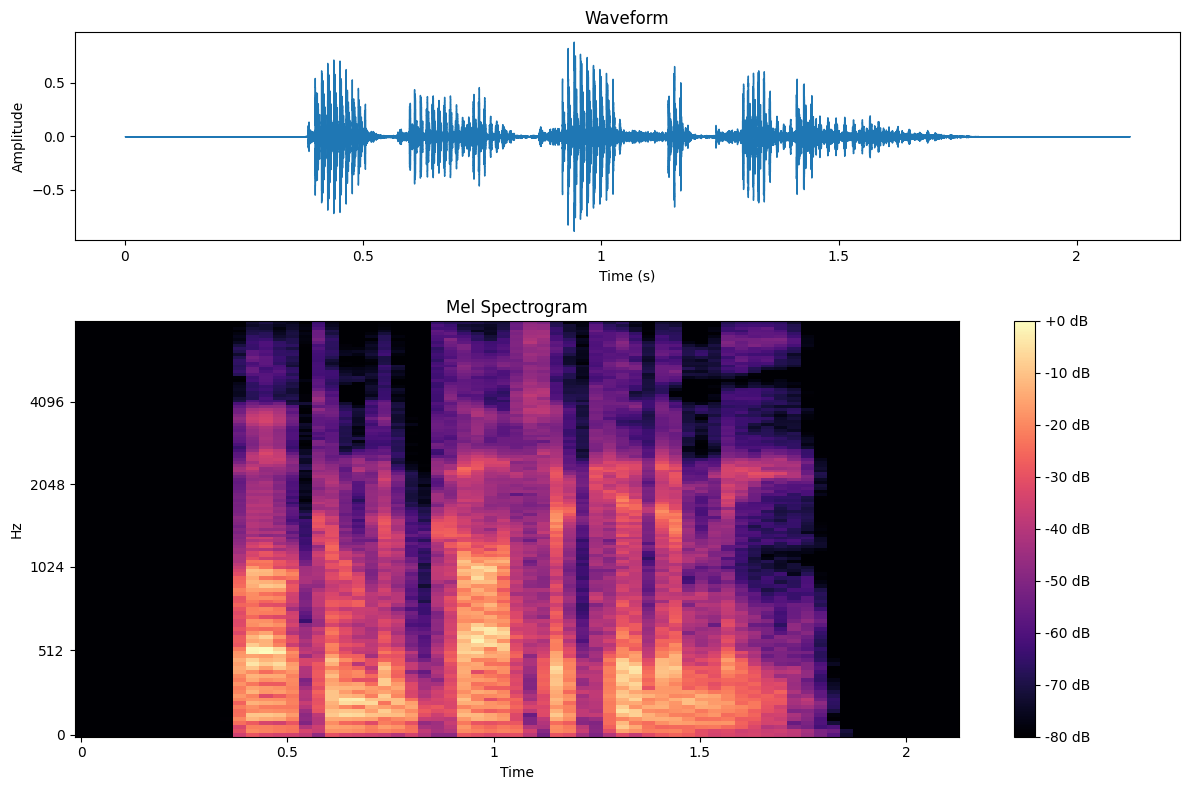

In [ ]:
# make sure to run the helper function cell before running this cell
file_path = "output_mms_tts.wav"
wav, sr = librosa.load(file_path, sr=16000)

fig, axs = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 2]})

# generate visualizations
visualize_waveform(wav, sr=sr, ax=axs[0])
generate_mel_spectrogram(wav, sr=sr, ax=axs[1])

plt.tight_layout()
plt.show()

### Task: Generate an Arabic utterance


Now create a sample utterance in the Arabic language. You may use whatever text you choose, but ensure it produces at least 5-10s of audio, and ensure your text is properly formatted for the input language you choose. Use the `use the facebook/mms-tts-ara`model checkpoint for this generation.

In [ ]:
#############################
#### YOUR CODE GOES HERE ####


#############################

### Task: Analyze synthesized utterances

Plot a Mel spectrogram of both the English and Arabic utterances you created. Can you identify markers of non-human speech by listening or visual inspection of the spectrogram?

* Describe what indicators you notice in the utterance that "gives away" the voice is computer generated. This can be aspects of the overall audio, specific pronunciations, or prosodic features of the utterance.
* In your plots try to annotate time ranges or specific time-frequency regions that show markers of non-human speech.

In [ ]:
#############################
#### YOUR CODE GOES HERE ####
# load audio, visualize two spectrograms. Comment/draw on any regions or overall muffle


#############################

### Task: Record/upload a sample utterance and check its quality

In [ ]:
#explicity defines record function again for new imports
import IPython.display as ipd
from base64 import b64decode


RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def record(sec=5):
  try:
    from google.colab import output
  except ImportError:
    print('No possible to import output from google.colab')
    return ''
  else:
    print('Recording')
    display(ipd.Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    fname = 'recorded_audio.wav'
    print('Saving to', fname)
    b = b64decode(s.split(',')[1])
    with open(fname, 'wb') as f:
      f.write(b)
    return fname

In [ ]:
# record your voice for at least 10 seconds
record(2)

Recording


<IPython.core.display.Javascript object>

Saving to recorded_audio.wav


'recorded_audio.wav'

In [ ]:
# IMPORTANT: your recordings are not permanently saved on Colab.
!mv recorded_audio.wav train_audio.ogg
!ffmpeg -y -i ./train_audio.ogg train_audio.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Now generate a spectrogram visualization of your utterance and listen to the audio to ensure you have good recording conditions and it sounds clear overall with minimal start/end silences

In [ ]:
#############################
#### YOUR CODE GOES HERE ####


#############################

### Using Bark

[Bark](https://github.com/suno-ai/bark) is a transformer-based model for generating audio from a text prompt. It's broader than just generating speech, it can generate non-speech noises including environmental sounds or signing. Bark is broad, but it is sometimes difficult to control -- the model may deviate from the prompt.

Let's generate some audio with Bark and compare it with our other TTS systems so far.

#### Setup



Before continuing, ensure the notebook runtime is set to T4 GPU.

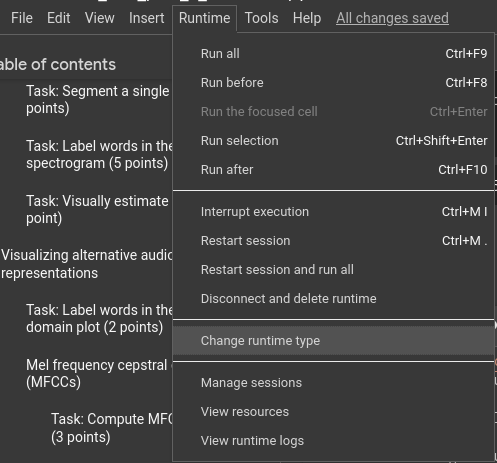

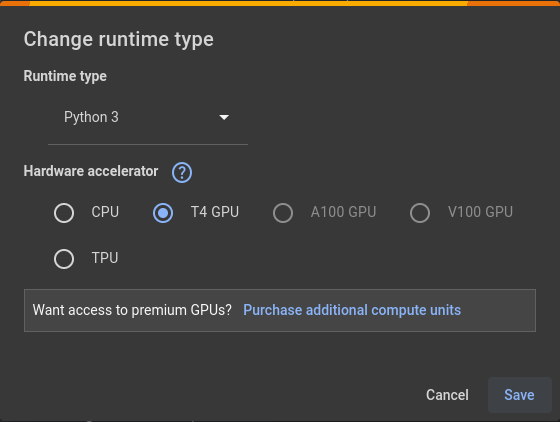

If you run out of memory, restart runtime session and try again.

In [ ]:
from transformers import AutoProcessor, BarkModel
from IPython.display import Audio
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

processor = AutoProcessor.from_pretrained("suno/bark")
model = BarkModel.from_pretrained("suno/bark").to("cuda")
model.cuda()

voice_preset = "v2/en_speaker_6"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

speaker_embeddings_path.json:   0%|          | 0.00/61.1k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/8.81k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/806 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/4.91k [00:00<?, ?B/s]

In [ ]:
# process and move inputs to CUDA
inputs = processor("Back in my day, I had to walk to school uphill... both ways", voice_preset=voice_preset)
inputs = {k: v.to("cuda") for k, v in inputs.items()}

# generate audio
bark_audio_array = model.generate(**inputs)

# move output to CPU for further processing
bark_audio_array = bark_audio_array.cpu().numpy().squeeze()
bark_sr = model.generation_config.sample_rate

Audio(data=bark_audio_array, rate=bark_sr)

speaker_embeddings/v2/en_speaker_6_seman(…):   0%|          | 0.00/2.60k [00:00<?, ?B/s]

speaker_embeddings/v2/en_speaker_6_coars(…):   0%|          | 0.00/7.55k [00:00<?, ?B/s]

speaker_embeddings/v2/en_speaker_6_fine_(…):   0%|          | 0.00/15.0k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'min_eos_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Now let's visualize the audio with waveshow and a melspectrogram.

NameError: name 'bark_audio_array' is not defined

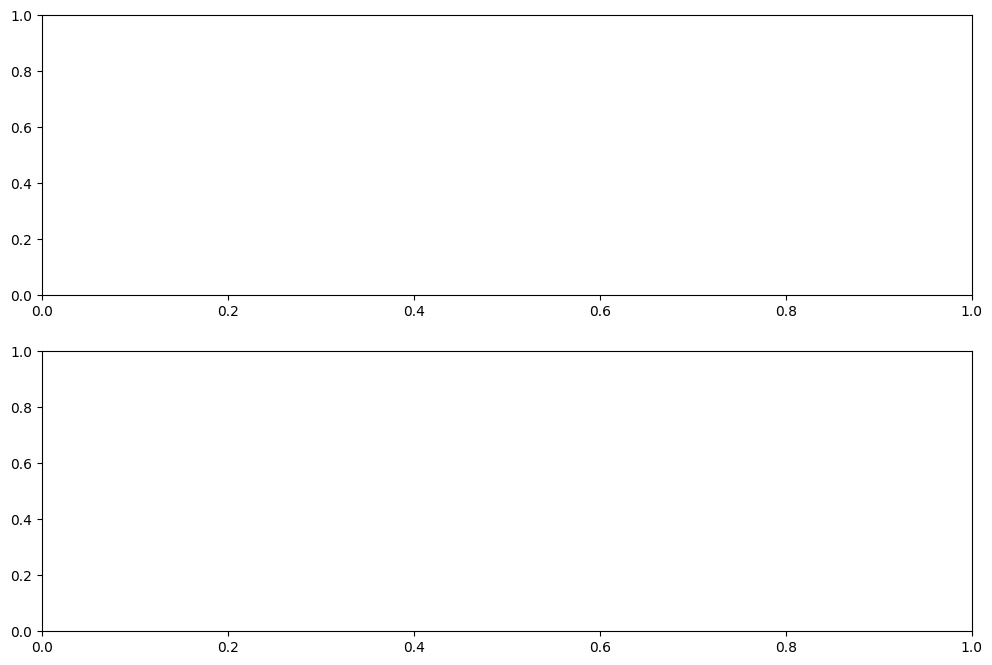

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

visualize_waveform(bark_audio_array, sr=bark_sr, ax=axes[0])
generate_mel_spectrogram(bark_audio_array, sr=bark_sr, ax=axes[1])

plt.tight_layout()
plt.show()

#### Task: Compare to normal TTS systems

Use Bark to generate at least one utterance with the same transcript as some of your previous utterances. Visualize the Bark samples you generate as a spectrogram.



In [ ]:
# Generate at least 1 sample for Bark. Visualize the utterance in a spectrogram

#############################
#### YOUR CODE GOES HERE ####


#############################


Comment on Bark vs traditional TTS approaches. Does Bark sound better as a TTS system in terms of naturalness? Expressiveness? Does Bark always remain faithful to the input transcript? You do not need to perform a full listening test comparison.

```
Your response here
```

#### Generating a voice clone sample from your input sample

In [ ]:
from scipy.io.wavfile import write as write_wav
from IPython.display import Audio, display

# Text to be synthesized
text_to_synthesize = "It took me quite a long time to develop a voice, and now that I have it I'm not going to be silent."

# Ensure processor and model are defined from previous cells (e.g., 54azVlImYDMQ)
# If they were not, you would need to uncomment and run the following lines:
# from transformers import AutoProcessor, BarkModel
# processor = AutoProcessor.from_pretrained("suno/bark")
# model = BarkModel.from_pretrained("suno/bark").to("cuda")

# Generate audio using the recorded voice as history_prompt with the transformers API
# 'train_audio.wav' was created in previous cells from your recording
inputs = processor(text_to_synthesize, history_prompt="train_audio.wav")
inputs = {k: v.to("cuda") for k, v in inputs.items()}

bark_audio_array = model.generate(**inputs)
bark_audio_array = bark_audio_array.cpu().numpy().squeeze()
bark_sr = model.generation_config.sample_rate

# Save the generated audio to a WAV file
output_filename = "output-en.wav"
write_wav(output_filename, bark_sr, bark_audio_array)

print(f"Generated voice clone saved to {output_filename}")

# Display the audio in the notebook
display(Audio(output_filename, rate=bark_sr))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://

Generated voice clone saved to output-en.wav


#### Task: Finding markers of non-human speech in visualizations

One way we might reveal that an utterance is from a TTS system rather than real human voice is via visualizing the time-domain and spectrogram plots to find indicators of TTS.

Create an utterance from your voice clone that fairly closely matches the words in the real voice audio sample you provided.

Visualize both the time domain and spectrogram of your original sample and the voice clone reproduction of your sample.

Adjust your plots to show any indicators the voice is not human (e.g. by zooming in or focusing on particular time/frequency ranges)

Describe and annotate in your plots as best you can any indicators you can find that would support a claim that the voice clone utterance does not come from a human.

In [ ]:
# Visualize an utterance with both spectrogram and time domain.
# Adjust your plots to show indicators this comes from TTS

#############################
#### YOUR CODE GOES HERE ####


#############################

#### Task: Generate and visualize an Arablc voice clone sample


Now, generate audio in the Arabic language using your cloned voice. For the `text` argument, you may choose what utterance to render, but ensure the text matches the input language you are using.

In [ ]:
#############################
#### YOUR CODE GOES HERE ####


#############################


Plot and compare your English and Arabic utterances. Do you notice any differences in the low-level acoustic features of your cloned voice when speaking other languages? Does the naturalness or expressivity of your voice seem affected?

In [ ]:
#############################
#### YOUR CODE GOES HERE ####


#############################

### Task: Generate audio that a normal TTS can't produce


Bark can do much more than a standard TTS system. Think of an application where you might want a mix of speech and other sounds, or heavily modified prosody. Generate at least one sample with Bark that a normal TTS system would not produce, and describe how Bark might support the application / use case you picked.

In [ ]:
# Generate at least 1 sample for Bark. Visualize the utterance in a spectrogram

#############################
#### YOUR CODE GOES HERE ####


#############################

Comment on applications where you might prefer Bark over traditional TTS.

```
Your response here
```